In [1]:
import analysis_fce as af

In [2]:
path = "C:/Users/kryst/OneDrive/Documents/Škola/Vysoká/bakalarska_prace/results/results_all"
save_path = "C:/Users/kryst/OneDrive/Documents/Škola/Konference/MME 2026/results/analysis/"

In [3]:
outlier_scenarios = {
    "1": ["50"],
    "2": ["50"],
    "3": ["50"],
    "4": ["50"],
    "5": ["50"],
    "6": ["50"],
    "7": ["50"],
    "8": ["50"]
}

In [4]:
base_coeff = {
    "X1": 0.8,
    "X2": -0.6,
    "X3": 0.6,
    "X4": -0.9,
}

base_with_lag = {**base_coeff, "X5": 0.0}  # X5 = target_lag
base_with_noncausal = {**base_coeff, "X5": 0.0}  # X5 = noncausal predictor
base_with_nonlinear_pred = {**base_coeff, "X5": -0.1}  # X5 = X4^2

nonlinear_coeff = {
    "X1": 0.0,
    "X2": 0.0,
    "X3": 0.1,
    "X4": -0.5,
}

nonlinear_all = {
    **nonlinear_coeff,
    "X5": 0.0,   # noncausal predictor
    "X6": -0.1,  # X4^2
    "X7": 0.0,   # target_lag
}

true_coeff_groups = {
    "1": base_coeff.copy(),            # Scenarios 1-3
    "2": base_coeff.copy(),            # Scenarios 4-6 (corr_m only)
    "3": base_with_lag.copy(),         # Scenarios 7-9 (auto_corr -> target_lag)
    "4": base_coeff.copy(),            # Scenarios 10-12 (noise_norm)
    "5": base_coeff.copy(),            # Scenarios 13-15 (omitted_var)
    "6": base_coeff.copy(),            # Scenarios 16-18 (endogeneity)
    "7": base_coeff.copy(),            # Scenarios 19-21 (heteroskedasticity)
    "8": base_coeff.copy(),            # Scenarios 22-24 (nonnormal_features)
    "9": base_with_nonlinear_pred.copy(),  # Scenarios 25-27 (nonlinear_predictor)
    "10": nonlinear_coeff.copy(),      # Scenarios 28-30 (nonlinear target)
    "11": base_with_noncausal.copy(),  # Scenarios 31-33 (noncausal_predictor)
    "12": nonlinear_all.copy(),        # Scenarios 34-36 (all violations)
}

In [4]:
df_coef = af.load_data(path, "coeff", 6)
df_std = af.load_data(path, "std_err", 6)

In [7]:
df_coef_clean, df_std_clean = af.remove_outliers(df_coef, outlier_scenarios, df_std)

Scenario: 1, N: 50 - Outliers: 58, NaNs: 0
Scenario: 2, N: 50 - Outliers: 67, NaNs: 1
Scenario: 3, N: 50 - Outliers: 0, NaNs: 0
Scenario: 4, N: 50 - Outliers: 0, NaNs: 0
Scenario: 5, N: 50 - Outliers: 0, NaNs: 0
Scenario: 6, N: 50 - Outliers: 0, NaNs: 0
Scenario: 7, N: 50 - Outliers: 0, NaNs: 0
Scenario: 8, N: 50 - Outliers: 0, NaNs: 0


In [8]:
df_coef_clean.shape, df_std_clean.shape

((2875, 6), (2875, 7))

In [9]:
coef_bias = af.calculate_coeff_bias(df_coef_clean, true_coeff_groups)

In [11]:
coef_bias_latex = af.bias_to_latex(coef_bias)

In [12]:
print(coef_bias_latex)

\begin{table}
\caption{Bias and RMSE of the estimated coefficients compared to the true coefficients for each scenario and N.}
\begin{tabular}{llrrrrrrrr}
\toprule
 & Coefficient & \multicolumn{2}{r}{X1} & \multicolumn{2}{r}{X2} & \multicolumn{2}{r}{X3} & \multicolumn{2}{r}{X4} \\
 &  & Bias & RMSE & Bias & RMSE & Bias & RMSE & Bias & RMSE \\
Scenario & N &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{1} & 50 & 0.197 & 0.624 & -0.127 & 0.504 & 0.105 & 0.540 & -0.130 & 0.546 \\
 & 500 & 0.012 & 0.132 & -0.012 & 0.140 & 0.028 & 0.140 & -0.023 & 0.148 \\
 & 5000 & 0.003 & 0.044 & -0.001 & 0.041 & 0.002 & 0.044 & -0.001 & 0.044 \\
\cline{1-10}
\multirow[t]{3}{*}{2} & 50 & 0.175 & 0.746 & -0.066 & 0.735 & 0.044 & 0.629 & -0.216 & 0.770 \\
 & 500 & 0.025 & 0.198 & -0.030 & 0.198 & 0.010 & 0.187 & -0.008 & 0.216 \\
 & 5000 & -0.001 & 0.056 & -0.000 & 0.060 & 0.000 & 0.054 & -0.001 & 0.062 \\
\cline{1-10}
\bottomrule
\end{tabular}
\end{table}



In [3]:
df_ml = af.load_data(path, "metrics_all", 9)

In [4]:
df_ml_res = af.calculate_ml_metric(df_ml, "Gini", "median")

In [5]:
caption = "Median Gini coefficient across scenarios and models."
print(af.ml_metric_to_latex(df_ml_res, caption))

\begin{table}
\caption{Median Gini coefficient across scenarios and models.}
\begin{tabular}{llrrrrr}
\toprule
 & Model & LR & LR (WOE) & NN & Náhodné lesy & XGBoost \\
Scenario & N &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{1} & 50 & 0.583 & 0.333 & 0.470 & 0.429 & 0.429 \\
 & 500 & 0.624 & 0.524 & 0.597 & 0.555 & 0.510 \\
 & 5000 & 0.626 & 0.604 & 0.621 & 0.599 & 0.604 \\
\cline{1-7}
\multirow[t]{3}{*}{2} & 50 & 0.667 & 0.423 & 0.524 & 0.571 & 0.520 \\
 & 500 & 0.666 & 0.605 & 0.647 & 0.618 & 0.580 \\
 & 5000 & 0.665 & 0.651 & 0.661 & 0.650 & 0.650 \\
\cline{1-7}
\multirow[t]{3}{*}{3} & 50 & 0.583 & 0.333 & 0.429 & 0.500 & 0.429 \\
 & 500 & 0.643 & 0.587 & 0.616 & 0.583 & 0.552 \\
 & 5000 & 0.647 & 0.634 & 0.641 & 0.627 & 0.630 \\
\cline{1-7}
\bottomrule
\end{tabular}
\end{table}



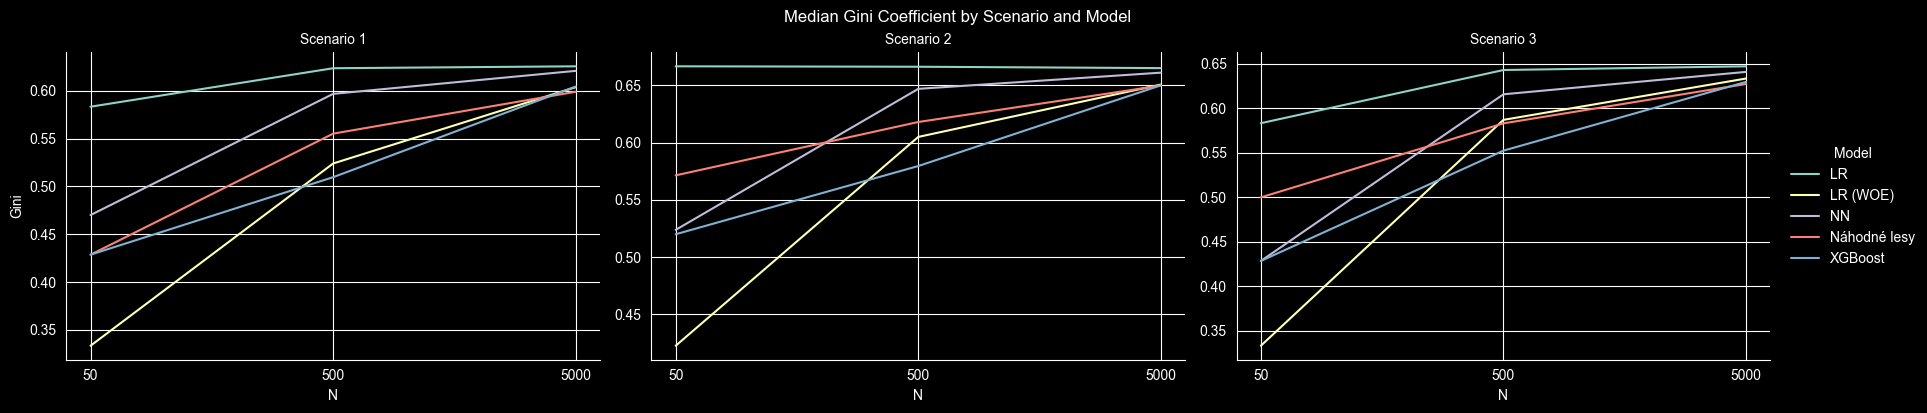

In [5]:
af.plot_ml_metric(df_ml_res, "Gini", "Median Gini Coefficient by Scenario and Model")

In [4]:
df_ml_res = af.calculate_ml_metric(df_ml, "Gini", "percent_best")

In [5]:
df_ml_res

Model,Scenario,N,LR,LR (WOE),NN,Náhodné lesy,XGBoost
0,1,50,45.6,13.8,30.6,23.4,22.8
1,1,500,63.2,4.8,25.0,5.6,4.0
2,1,5000,77.0,0.6,20.2,0.6,1.6
3,2,50,46.4,17.2,32.0,25.0,22.8
4,2,500,56.4,10.8,25.2,5.8,3.6
5,2,5000,69.8,2.0,25.2,1.8,1.6
6,3,50,42.6,17.6,28.8,26.0,21.6
7,3,500,56.6,10.4,24.8,7.0,3.0
8,3,5000,80.0,2.2,15.6,0.8,1.4


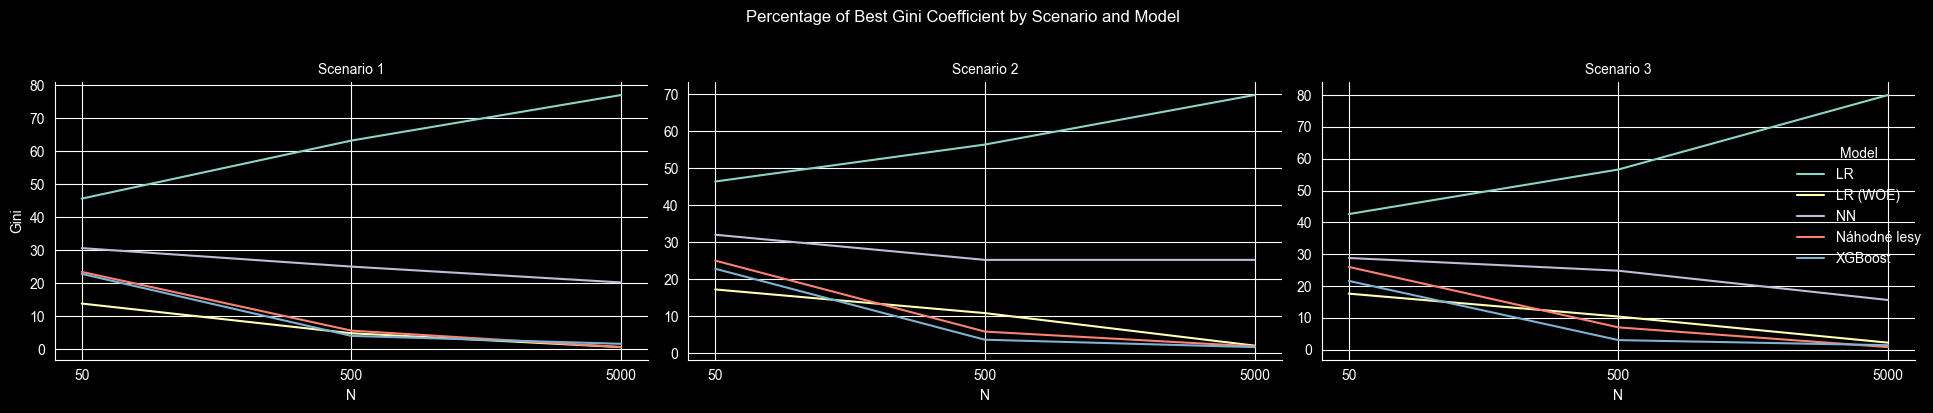

In [6]:
af.plot_ml_metric(df_ml_res, "Gini", "Percentage of Best Gini Coefficient by Scenario and Model")